Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/6_full_2025_09_10__23_05_36(1).czi


/var/folders/50/n9bczqz13x15_hwcgklh8kyh0000gp/T/ipykernel_26793/2662100381.py:90: RuntimeWarning: Mean of empty slice.
  ratio = intens_in.mean() / intens_out.mean()
/Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/Hackathon/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


TypeError: Input z must be 2D, not 1D

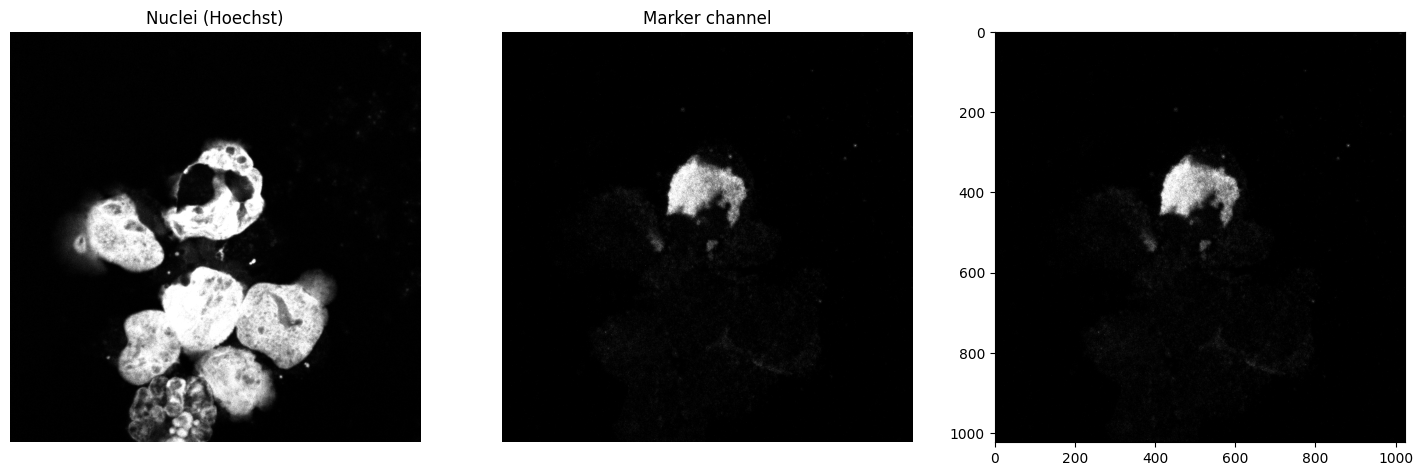

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from czifile import CziFile
from cellpose import models
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
FOLDER = "/Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/"   # <-- change
NUCLEI_DIAMETER = 100
MARKER_DIAMETER = 200
OVERLAP_THRESHOLD = 0.30

all_ratios = []

model = models.CellposeModel(gpu=False, model_type='nuclei')

# ---------------------------------------------------------
# LOOP OVER ALL FILES
# ---------------------------------------------------------
files = glob(FOLDER + "/*.czi")

for file in files:
    print("Processing:", file)

    # -----------------------------
    # Load image
    # -----------------------------
    czi = CziFile(file)
    img = np.squeeze(czi.asarray())

    marker_img = img[0].astype(np.float32)
    nuclei_img = img[3].astype(np.float32)

    # -----------------------------
    # Segment nuclei
    # -----------------------------
    nuc_masks, _, _ = model.eval(
        nuclei_img, channels=[0,0],
        diameter=NUCLEI_DIAMETER,
        cellprob_threshold=0.1,
        flow_threshold=0.4
    )

    # -----------------------------
    # Segment marker-positive regions
    # -----------------------------
    marker_masks, _, _ = model.eval(
        marker_img, channels=[0,0],
        diameter=MARKER_DIAMETER,
        cellprob_threshold=1.0,
        flow_threshold=0.7
    )

    # -----------------------------
    # Select nuclei overlapping marker mask
    # -----------------------------
    selected = set()
    for region in regionprops(nuc_masks):
        coords = region.coords
        overlap = np.sum(marker_masks[coords[:,0], coords[:,1]] > 0)
        frac = overlap / len(coords)
        if frac >= OVERLAP_THRESHOLD:
            selected.add(region.label)

    filtered_nuclei = np.zeros_like(nuc_masks)
    for region in regionprops(nuc_masks):
        if region.label in selected:
            filtered_nuclei[region.coords[:,0], region.coords[:,1]] = region.label

    # -----------------------------
    # Compute inside/outside ratio
    # -----------------------------
    ratios_this_file = []

    for region in regionprops(marker_masks, intensity_image=marker_img):
        coords = region.coords
        intens = marker_img[coords[:,0], coords[:,1]]
        inside = filtered_nuclei[coords[:,0], coords[:,1]] > 0

        intens_in = intens[inside]
        intens_out = intens[~inside]

        if len(intens_out) == 0:
            continue

        ratio = intens_in.mean() / intens_out.mean()
        ratios_this_file.append(ratio)

    all_ratios.extend(ratios_this_file)

    # -----------------------------
    # Representative images (3 panels)
    # -----------------------------
    fig, ax = plt.subplots(1, 3, figsize=(18,6))

    # 1. Raw channels
    ax[0].imshow(nuclei_img, cmap='gray')
    ax[0].set_title("Nuclei (Hoechst)")
    ax[0].axis('off')

    ax[1].imshow(marker_img, cmap='gray')
    ax[1].set_title("Marker channel")
    ax[1].axis('off')

    # 2. Combined outlines
    ax[2].imshow(marker_img, cmap='gray')
    for c in find_boundaries(filtered_nuclei > 0):
        ax[2].contour(c, colors='cyan', linewidths=1)
    for c in find_boundaries(marker_masks > 0):
        ax[2].contour(c, colors='yellow', linewidths=1)
    ax[2].set_title("Selected nuclei (cyan) + marker (yellow)")
    ax[2].axis('off')

    plt.suptitle(f"Representative images for {file}")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# FINAL BOXPLOT
# ---------------------------------------------------------
plt.figure(figsize=(6,6))
plt.boxplot(all_ratios)
plt.ylabel("Mean intensity ratio (inside / outside)")
plt.title("Distribution of marker enrichment across all files")
plt.show()


Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/6_6.czi


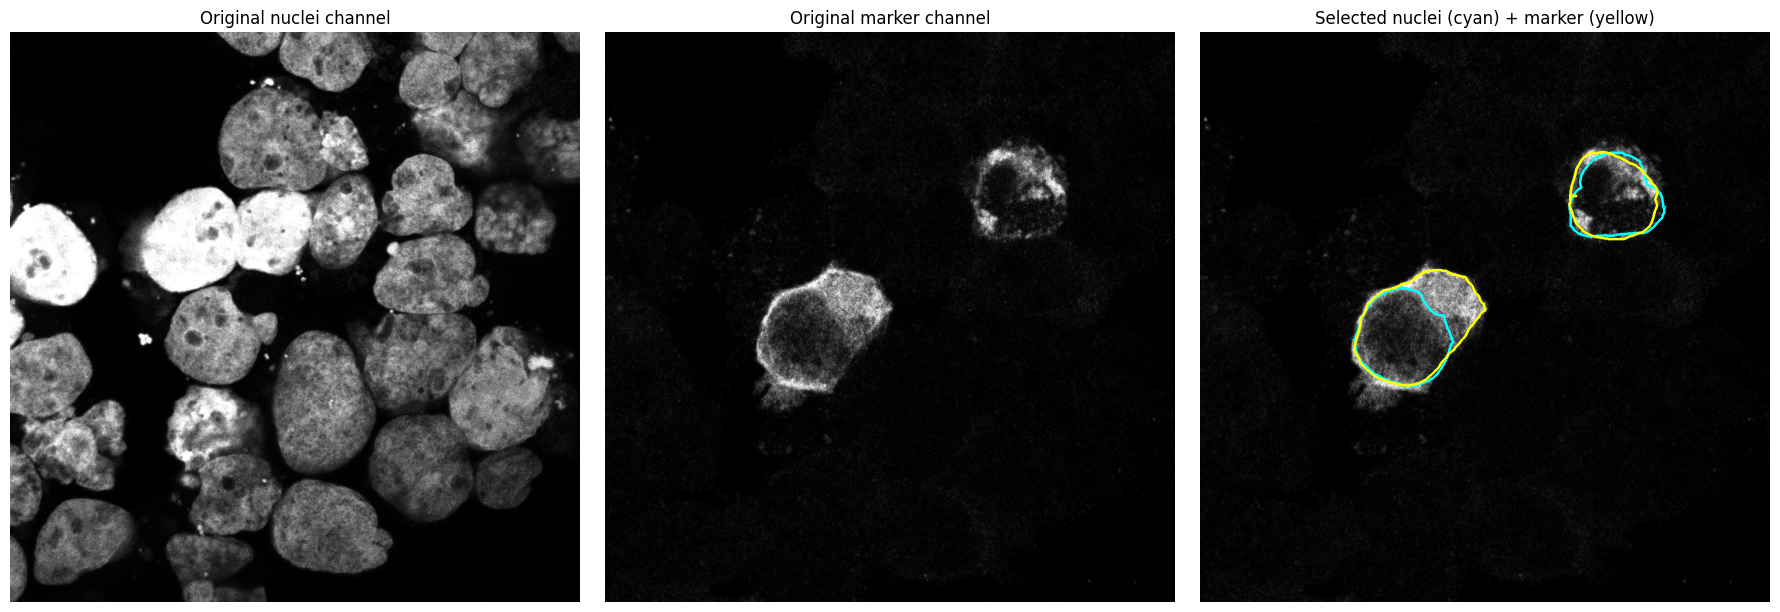

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/6_5.czi


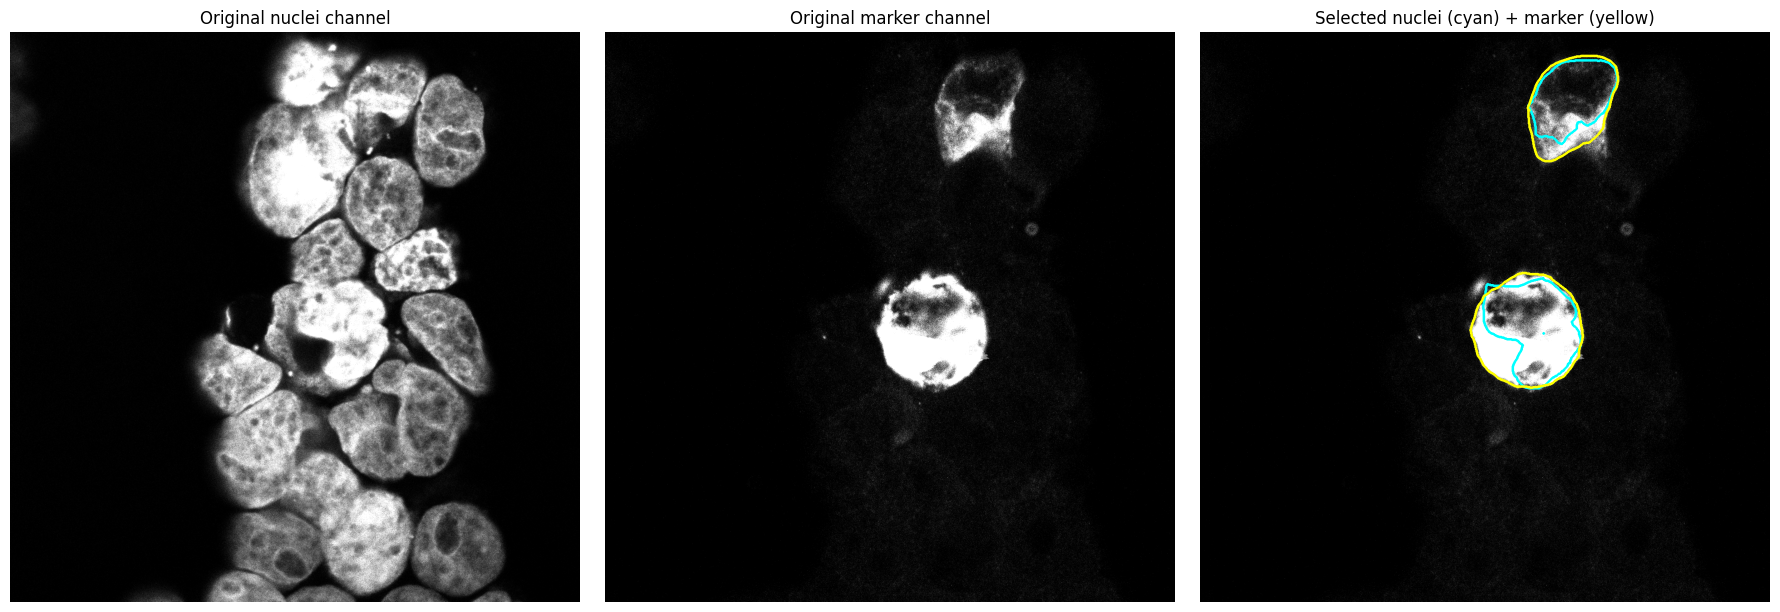

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/6_4.czi


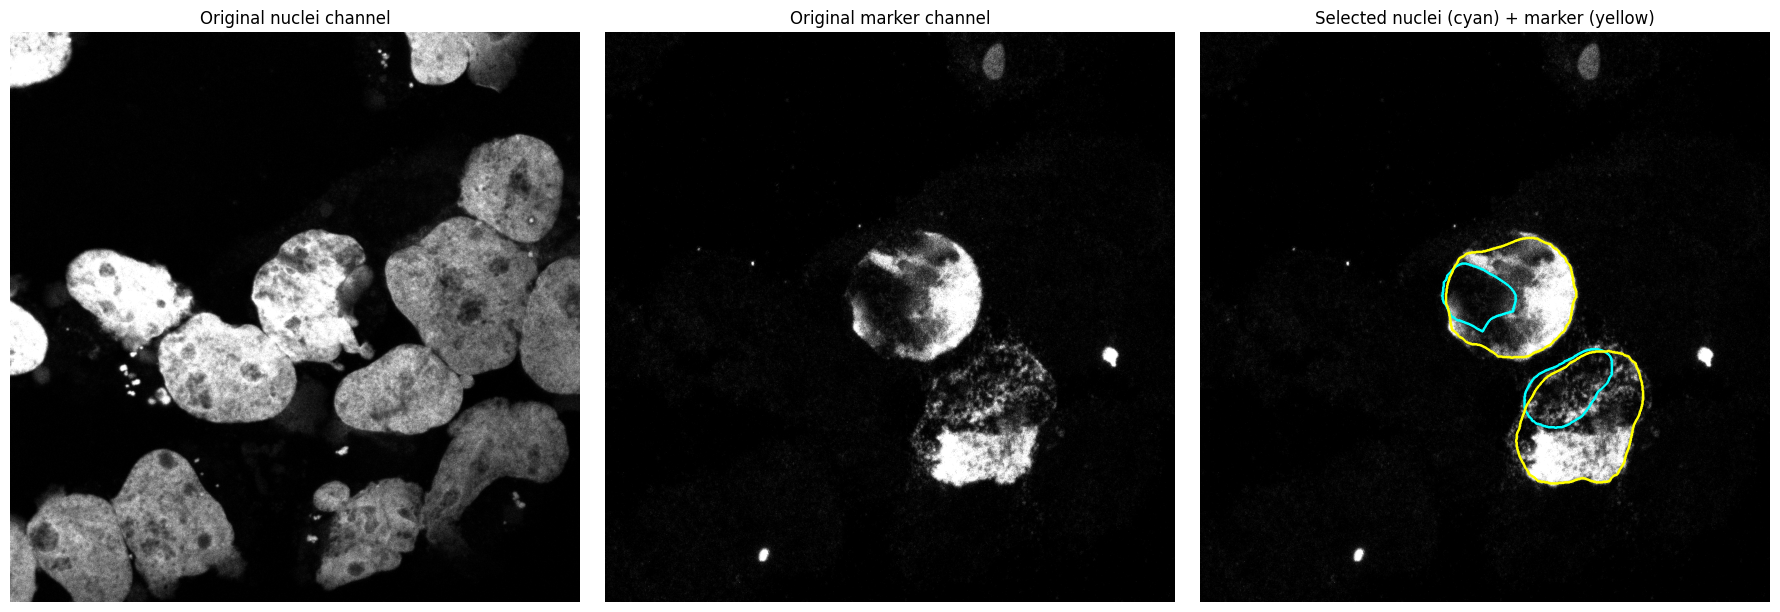

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/6_1.czi


/var/folders/50/n9bczqz13x15_hwcgklh8kyh0000gp/T/ipykernel_26793/4174527909.py:130: RuntimeWarning: Mean of empty slice.
  ratio = intens_in.mean() / intens_out.mean()
/Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/Hackathon/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


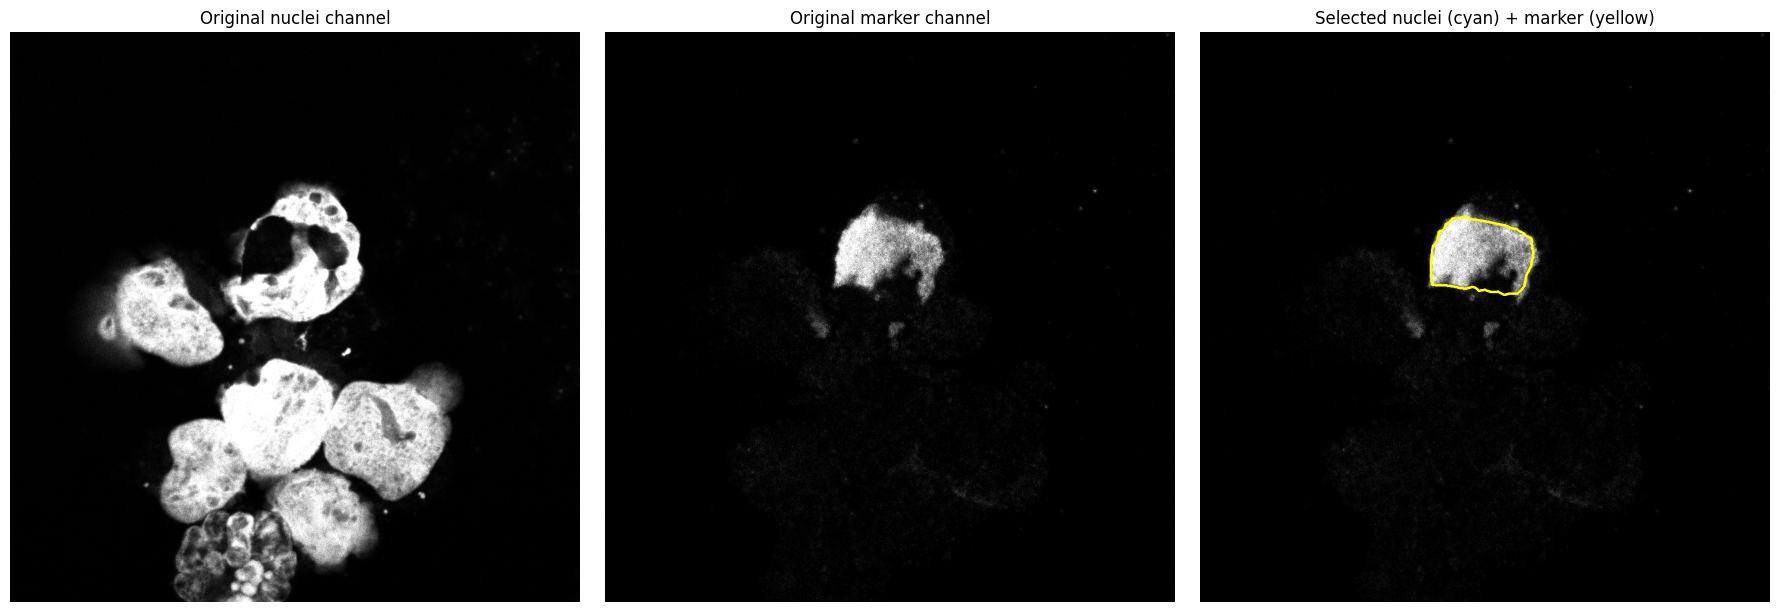

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/6_3.czi


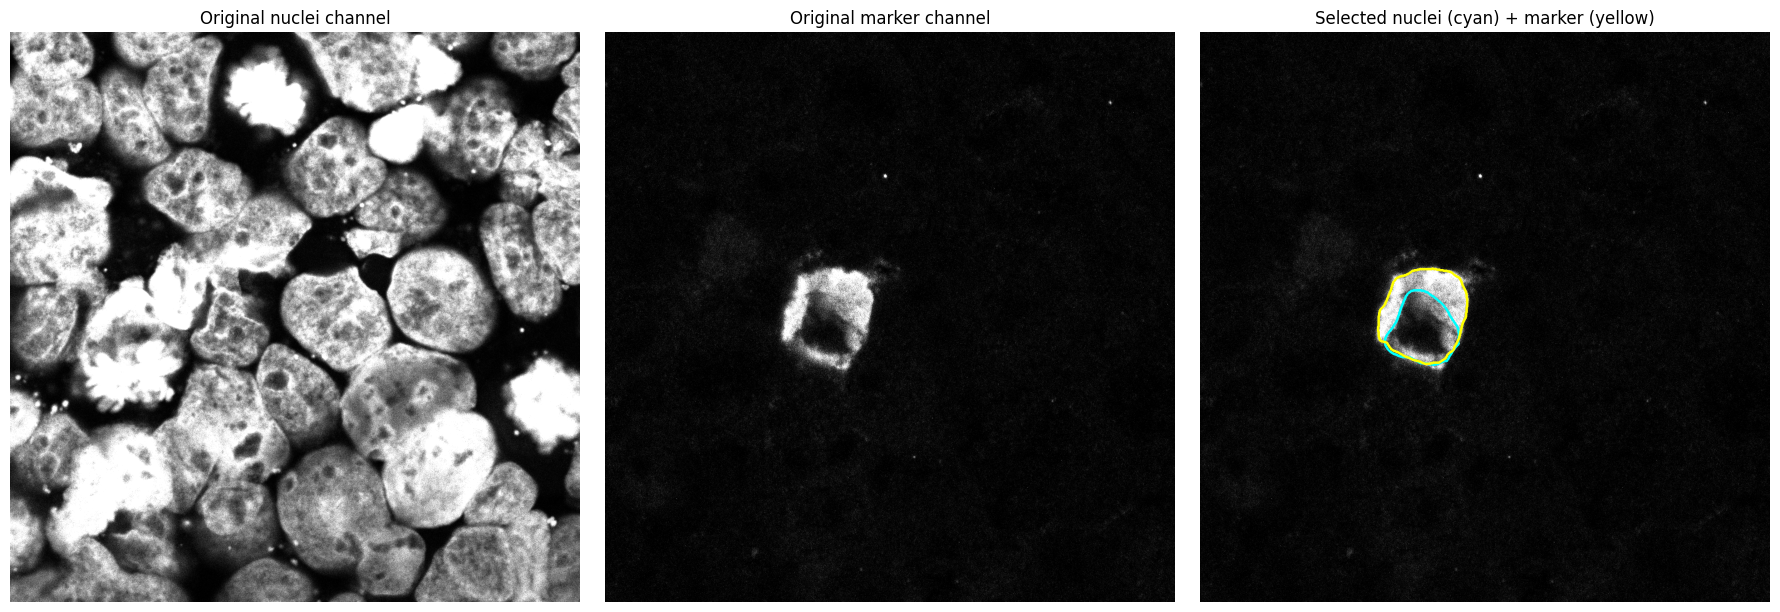

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/6_2.czi


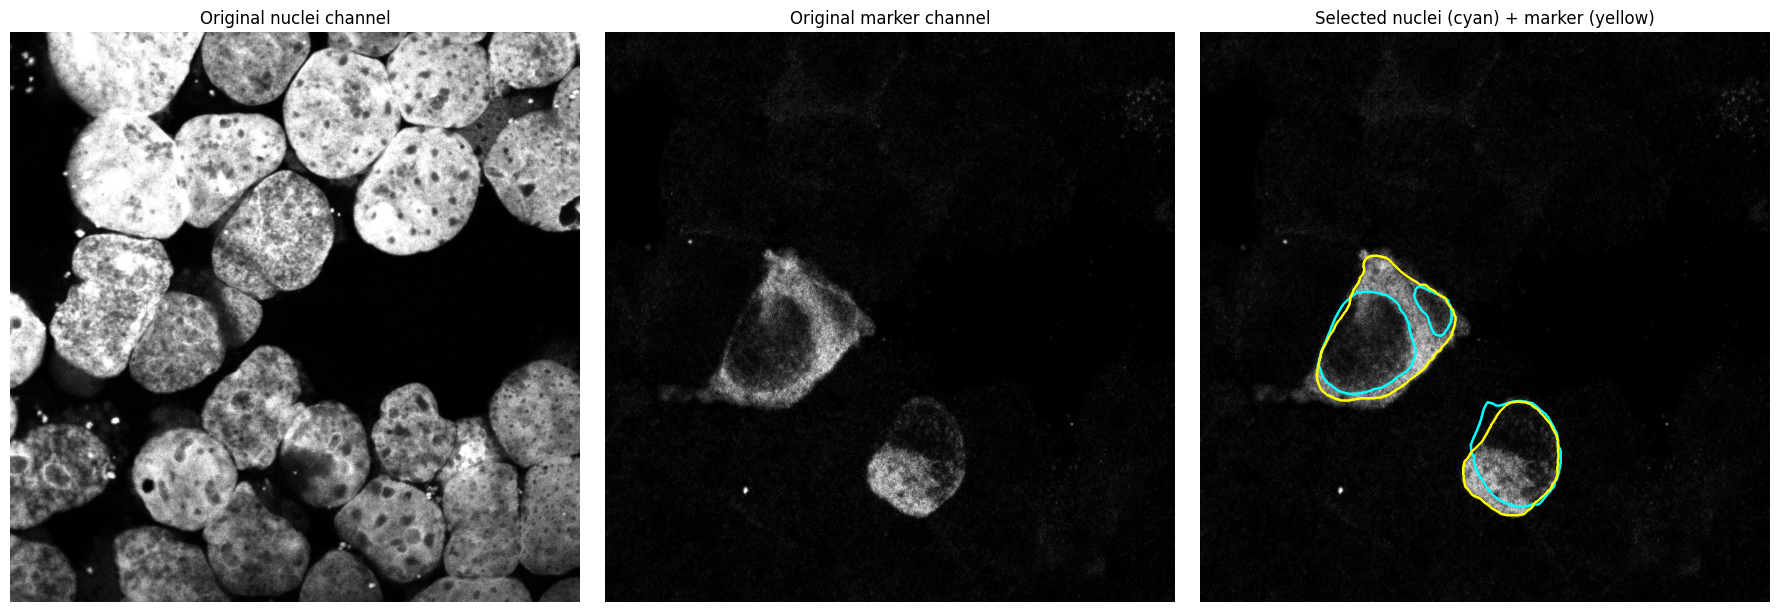

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/7_5.czi


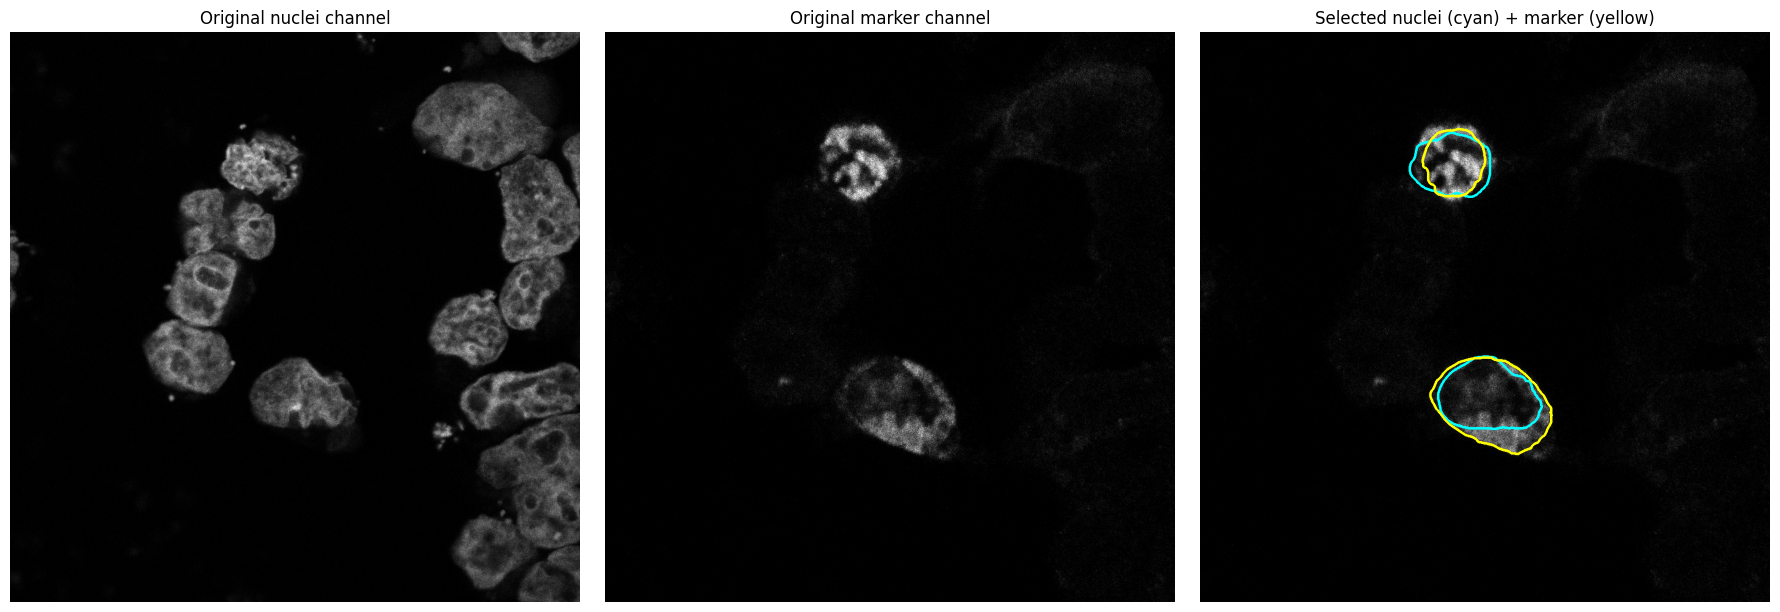

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/7_4.czi


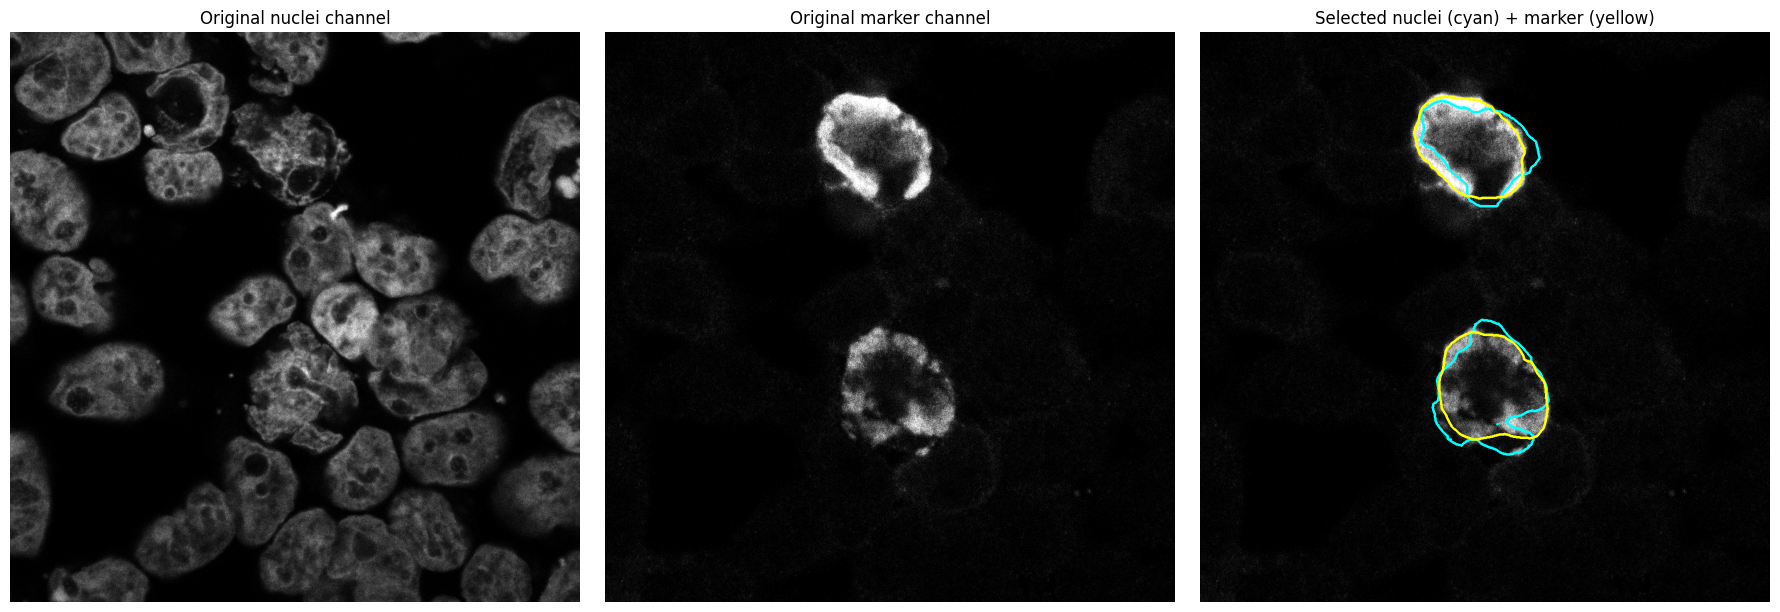

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/7_6.czi


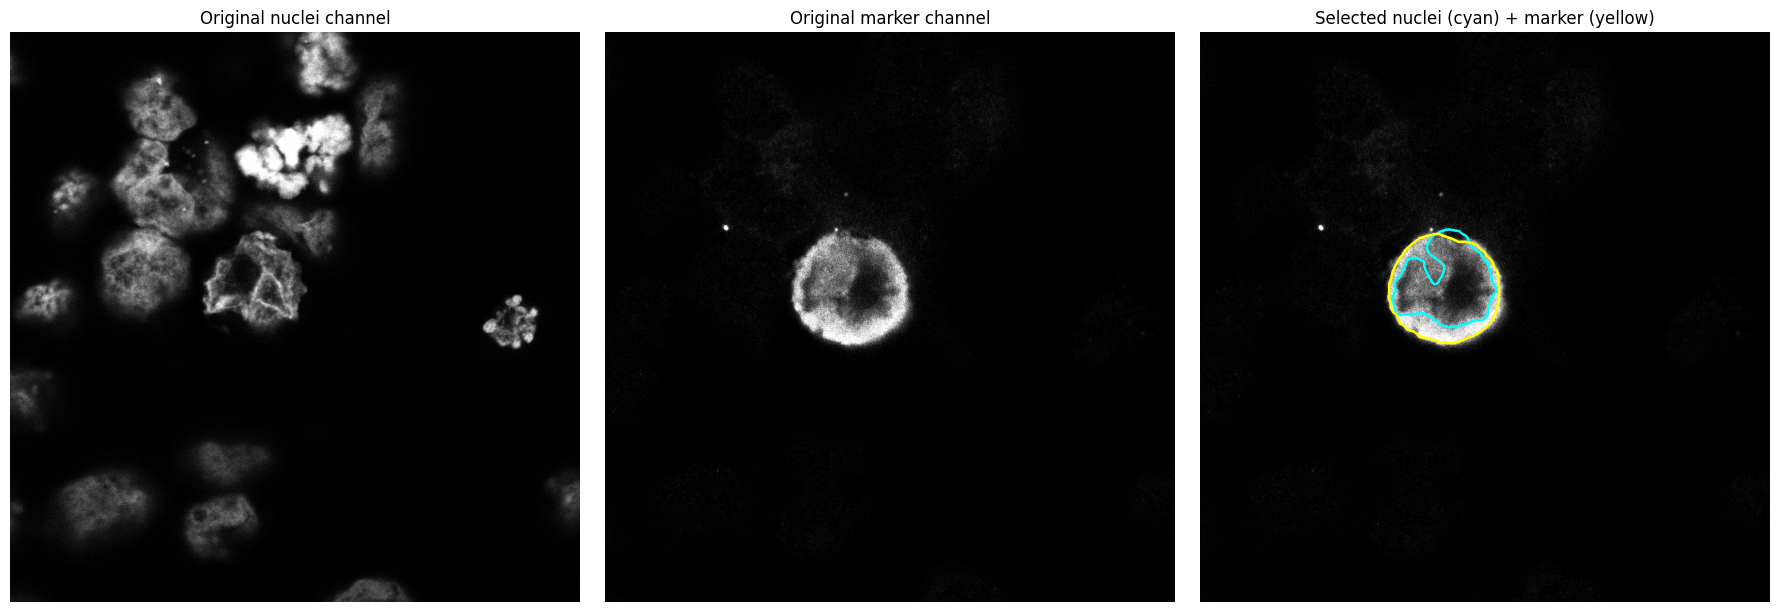

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/7_3.czi


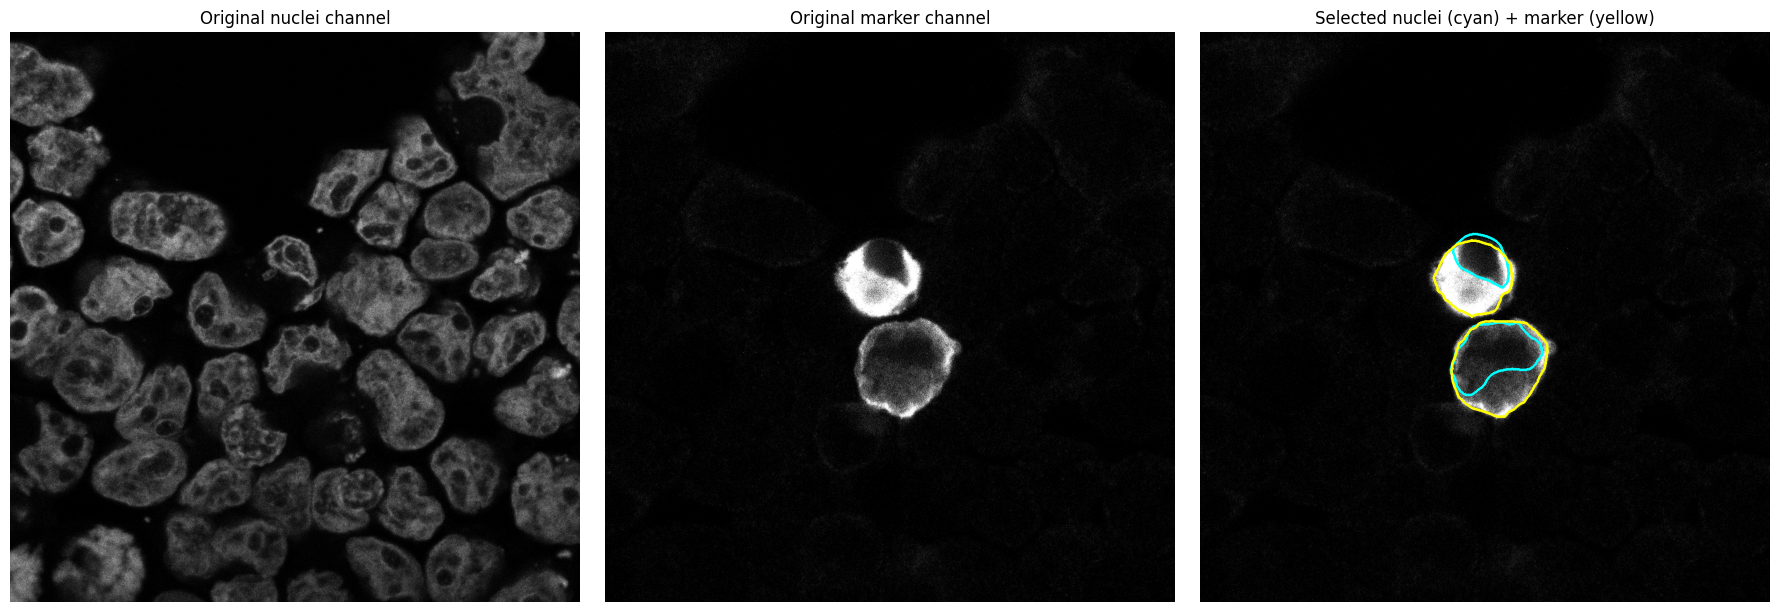

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/7_2.czi


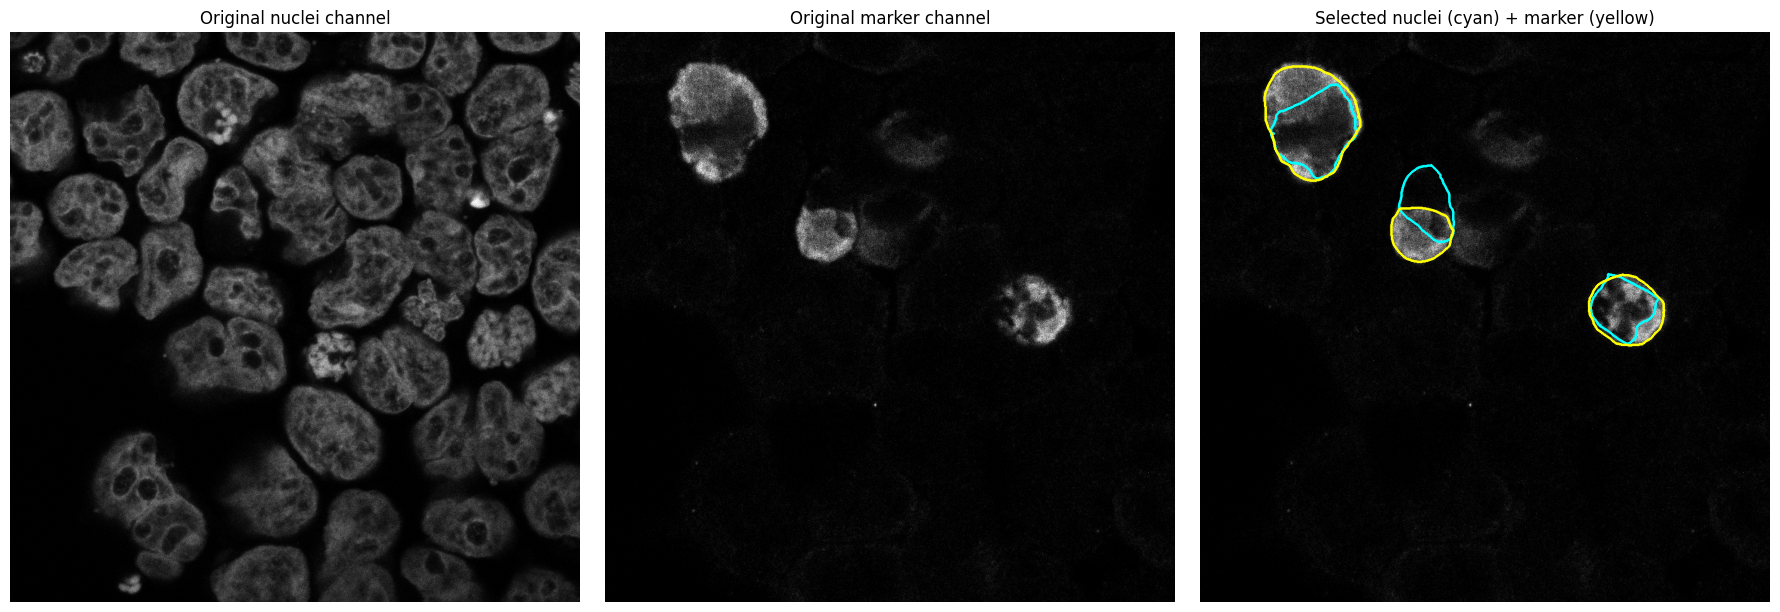

Processing: /Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/7_1.czi


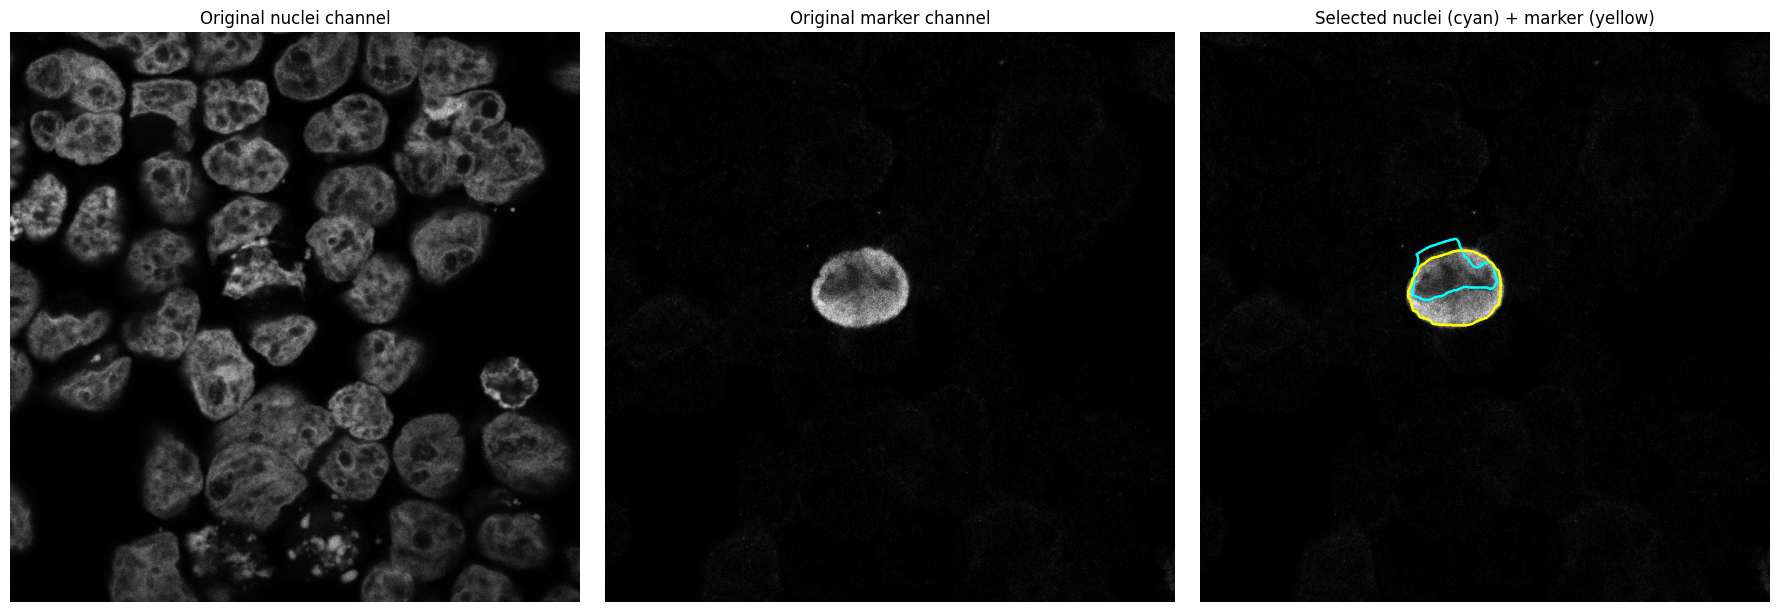

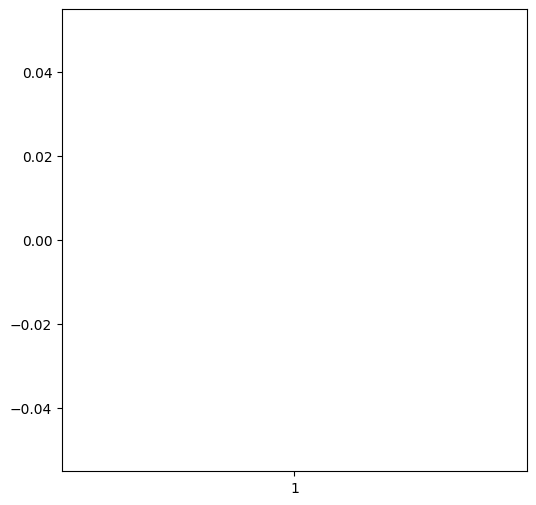

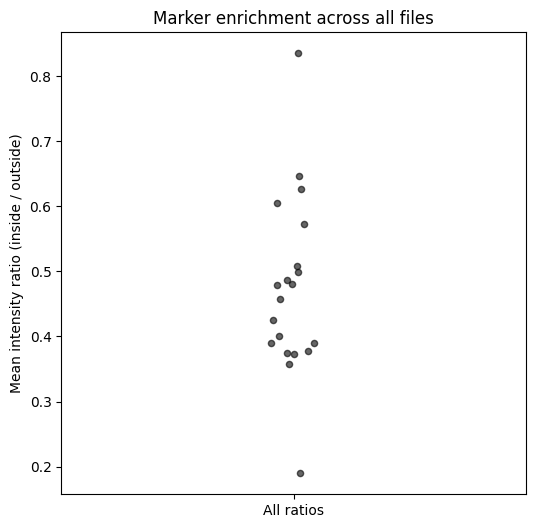

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from czifile import CziFile
from cellpose import models
from skimage.filters import gaussian
from skimage import exposure
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries
import os
import pandas as pd

OUT = "results/"
os.makedirs(OUT, exist_ok=True)
os.makedirs(f"{OUT}/images", exist_ok=True)
os.makedirs(f"{OUT}/per_file_csv", exist_ok=True)


# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
FOLDER = "/Users/u5672638/Library/CloudStorage/OneDrive-UniversityofWarwick/FS_26/Hackathon/1.data/test/"   # <-- change
OVERLAP_THRESHOLD = 0.30

# Your original filtering thresholds
MIN_AREA = 5000
MIN_MEAN_INTENSITY = 7000

all_ratios = []

# Cellpose model (same as your script)
model = models.CellposeModel(gpu=False, model_type='nuclei')

# ---------------------------------------------------------
# LOOP OVER ALL FILES
# ---------------------------------------------------------
files = glob(FOLDER + "/*.czi")

for file in files:
    print("Processing:", file)

    # -----------------------------
    # Load + squeeze
    # -----------------------------
    czi = CziFile(file)
    img = np.squeeze(czi.asarray())

    # -----------------------------
    # Extract channels (your choice)
    # -----------------------------
    marker_img_orig = img[0].astype(np.float32)
    nuclei_img_orig = img[3].astype(np.float32)

    # -----------------------------
    # Smoothing + contrast (your exact pipeline)
    # -----------------------------
    marker_smooth = gaussian(marker_img_orig, sigma=2)
    marker_gamma = exposure.adjust_gamma(marker_smooth, gamma=0.5)

    nuclei_smooth = gaussian(nuclei_img_orig, sigma=2)
    nuclei_gamma = exposure.adjust_gamma(nuclei_smooth, gamma=0.7)

    marker_img = marker_gamma
    nuclei_img = nuclei_gamma

    # -----------------------------
    # Nuclei segmentation (your parameters)
    # -----------------------------
    nuc_masks, _, _ = model.eval(
        nuclei_img,
        channels=[0, 0],
        diameter=100,
        cellprob_threshold=0.1,
        flow_threshold=0.4
    )

    # -----------------------------
    # Marker segmentation (your parameters)
    # -----------------------------
    marker_masks, _, _ = model.eval(
        marker_img,
        channels=[0, 0],
        diameter=200,
        cellprob_threshold=1,
        flow_threshold=0.7
    )
        # -----------------------------
    # FILTER MARKER MASKS
    # -----------------------------
    filtered_marker_masks = np.zeros_like(marker_masks)

    for region in regionprops(marker_masks, intensity_image=marker_img_orig):
        if region.area >= MIN_AREA and region.mean_intensity >= MIN_MEAN_INTENSITY:
            filtered_marker_masks[region.coords[:,0], region.coords[:,1]] = region.label

    marker_masks = filtered_marker_masks

    # -----------------------------
    # Select nuclei overlapping marker mask
    # -----------------------------
    selected = set()
    for region in regionprops(nuc_masks):
        coords = region.coords
        overlap = np.sum(marker_masks[coords[:,0], coords[:,1]] > 0)
        frac = overlap / len(coords)
        if frac >= OVERLAP_THRESHOLD:
            selected.add(region.label)

    filtered_nuclei = np.zeros_like(nuc_masks)
    for region in regionprops(nuc_masks):
        if region.label in selected:
            filtered_nuclei[region.coords[:,0], region.coords[:,1]] = region.label

    # -----------------------------
    # Compute inside/outside ratio
    # -----------------------------
    ratios_this_file = []

    for region in regionprops(marker_masks, intensity_image=marker_img_orig):
        coords = region.coords
        intens = marker_img_orig[coords[:,0], coords[:,1]]
        inside = filtered_nuclei[coords[:,0], coords[:,1]] > 0

        intens_in = intens[inside]
        intens_out = intens[~inside]

        if len(intens_out) == 0:
            continue

        ratio = intens_in.mean() / intens_out.mean()
        ratios_this_file.append(ratio)

    all_ratios.extend(ratios_this_file)

    # -----------------------------
    # Representative images (presentation-ready)
    # -----------------------------
    fig, ax = plt.subplots(1, 3, figsize=(18,6))

    ax[0].imshow(nuclei_img_orig, cmap='gray')
    ax[0].set_title("Original nuclei channel")
    ax[0].axis('off')

    ax[1].imshow(marker_img_orig, cmap='gray')
    ax[1].set_title("Original marker channel")
    ax[1].axis('off')

    ax[2].imshow(marker_img_orig, cmap='gray')
    ax[2].set_title("Selected nuclei (cyan) + marker (yellow)")
    ax[2].axis('off')

    # outlines
    nuc_boundary = find_boundaries(filtered_nuclei > 0)
    marker_boundary = find_boundaries(marker_masks > 0)

    ax[2].contour(nuc_boundary, colors='cyan', linewidths=1)
    ax[2].contour(marker_boundary, colors='yellow', linewidths=1)

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# FINAL BOXPLOT
# ---------------------------------------------------------
plt.figure(figsize=(6,6))
plt.boxplot(all_ratios)
plt.figure(figsize=(6,6))

# Boxplot
plt.boxplot(all_ratios, positions=[1])

# Scatter (all dots)
x = np.ones(len(all_ratios))  # all points at x=1
# add jitter so points don't overlap
x_jitter = x + (np.random.rand(len(all_ratios)) - 0.5) * 0.1

plt.scatter(x_jitter, all_ratios, color='black', alpha=0.6, s=20)

plt.ylabel("Mean intensity ratio (inside / outside)")
plt.title("Marker enrichment across all files")
plt.xticks([1], ["All ratios"])

plt.show()


df_all = pd.DataFrame({"ratio_inside_outside": all_ratios})
df_all.to_csv(f"{OUT}/all_ratios.csv", index=False)

